In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the prepared dataset
df = pd.read_csv('../data/prepared_trader_sentiment.csv')

In [3]:
# 1. Aggregate lifetime metrics per Trader (Account)
trader_profiles = df.groupby('Account').agg(
    total_lifetime_trades=('total_trades', 'sum'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    lifetime_pnl=('daily_pnl', 'sum')
).reset_index()

# Drop NaNs
trader_profiles = trader_profiles.dropna()

In [4]:
# 2.features for clustering
features = ['total_lifetime_trades','avg_win_rate','avg_trade_size']
X = trader_profiles[features]

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 3. Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

# We will calculate the mean of each cluster to see what they represent
cluster_summary = trader_profiles.groupby('Cluster')[features + ['lifetime_pnl']].mean()

# This assigns names based on who trades the most, who trades the biggest, etc.
cluster_names = {}
for c in range(3):
    if cluster_summary.loc[c, 'avg_trade_size'] == cluster_summary['avg_trade_size'].max():
        cluster_names[c] = 'The Whales (High Size)'
    elif cluster_summary.loc[c, 'total_lifetime_trades'] == cluster_summary['total_lifetime_trades'].max():
        cluster_names[c] = 'The High-Frequency Scalpers'
    else:
        cluster_names[c] = 'The Retail Average'

trader_profiles['Archetype'] = trader_profiles['Cluster'].map(cluster_names)

print("--- Trader Archetype Summary ---")
print(trader_profiles.groupby('Archetype')[['total_lifetime_trades', 'avg_win_rate', 'avg_trade_size', 'lifetime_pnl']].mean())

--- Trader Archetype Summary ---
                             total_lifetime_trades  avg_win_rate  \
Archetype                                                          
The High-Frequency Scalpers           21145.000000      0.507423   
The Retail Average                     4270.904762      0.319593   
The Whales (High Size)                 5279.285714      0.359640   

                             avg_trade_size   lifetime_pnl  
Archetype                                                   
The High-Frequency Scalpers     2531.989168  571951.145141  
The Retail Average              5020.673417  215384.515020  
The Whales (High Size)         23798.650028  498011.363923  


C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


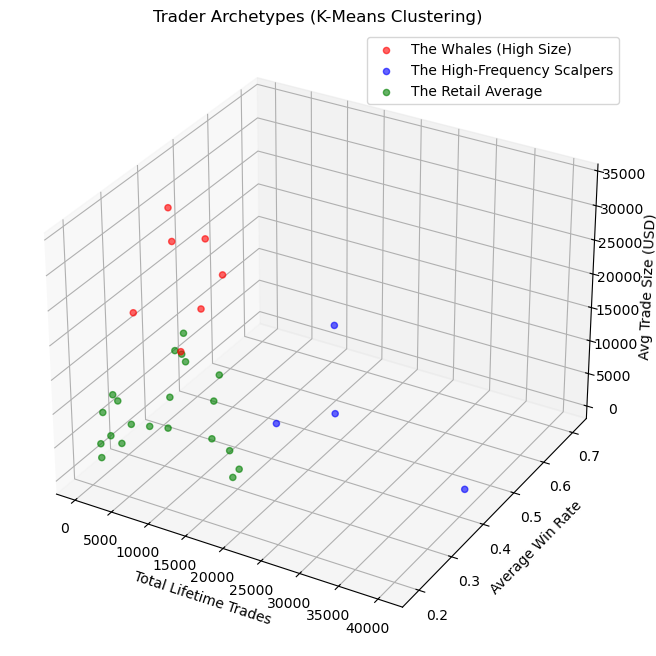

In [6]:
# 4. Visualization: 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'The Whales (High Size)': 'red', 'The High-Frequency Scalpers': 'blue', 'The Retail Average': 'green'}

for archetype, color in colors.items():
    subset = trader_profiles[trader_profiles['Archetype'] == archetype]
    ax.scatter(subset['total_lifetime_trades'], 
               subset['avg_win_rate'], 
               subset['avg_trade_size'], 
               c=color, label=archetype, alpha=0.6)

ax.set_xlabel('Total Lifetime Trades')
ax.set_ylabel('Average Win Rate')
ax.set_zlabel('Avg Trade Size (USD)')
ax.set_title('Trader Archetypes (K-Means Clustering)')
plt.legend()
plt.show()

In [7]:
trader_profiles.to_csv('../data/trader_profiles_clustered.csv', index=False)